# Satellite Image Classification (Urban vs. Natural) Using Classical Vision + ML
**Course:** Computer Vision (S2-25_AIMLCZG525)

Build a classical machine-learning system that classifies satellite images into Urban or Natural categories using handcrafted image features. The system must incorporate pixel level, texture, and gradient-based features and evaluate performance on a real external image.

---

### Pipeline Overview
1. Dataset Preparation (EuroSAT – Urban vs Natural, ~500 each)
2. Preprocessing (resize, grayscale, CLAHE, Gaussian blur)
3. Feature Engineering (Histogram, LBP, Edges, HOG)
4. Feature Selection (PCA)
5. Model Training (SVM + Random Forest, 5-fold CV)
6. Evaluation (Accuracy, Precision, Recall, F1, Confusion Matrix)
7. Model Inference – 5 Random Test Images
8. External Real-World Image Validation
9. Analysis & Discussion

---
## Part 0 – Import Required Libraries

In [ ]:
# ── Standard Library ──────────────────────────────────────────────────────────
import os
import random
import warnings
import pickle
import kagglehub # Moved here
warnings.filterwarnings('ignore') # Ignoring warnings broadly for cleaner notebook output

# ── Numerical & Data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Image Processing ──────────────────────────────────────────────────────────
import cv2                                      # OpenCV for image I/O and processing
from skimage.feature import hog, local_binary_pattern  # HOG and LBP
from skimage import exposure
import skimage # Import skimage to get its version

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline
import sklearn # Import sklearn to get its version

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("All libraries imported successfully.")
print(f"   OpenCV       : {cv2.__version__}")
print(f"   NumPy        : {np.__version__}")
print(f"   Pandas       : {pd.__version__}")
print(f"   Scikit-image : {skimage.__version__}") # Added
print(f"   Scikit-learn : {sklearn.__version__}") # Added

✅ All libraries imported successfully.
   OpenCV       : 4.13.0
   NumPy        : 2.0.2
   Pandas       : 2.2.2
   Scikit-image : 0.25.2
   Scikit-learn : 1.6.1


---
## Part 1 – Dataset Preparation

### 1.1 Dataset – EuroSAT

For this assignment, the EuroSAT dataset is downloaded via KaggleHub. We then extract **~500 Urban** and **~500 Natural** images by mapping EuroSAT's 10 classes into these two broader categories.

**Urban classes** (mapped from EuroSAT): `Residential`, `Industrial`, `Highway`  
**Natural classes** (mapped from EuroSAT): `Forest`, `River`, `SeaLake`, `Pasture`, `PermanentCrop`, `HerbaceousVegetation`, `AnnualCrop`

The data loading code handles the extraction and mapping automatically; no manual folder creation is required.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION - adjust paths before running
# ─────────────────────────────────────────────────────────────────────────────
DATA_DIR       = 'data'
IMG_SIZE       = (128, 128)
MAX_PER_CLASS  = 500             # cap to keep runtime manageable
FEATURES_FILE  = 'features.pkl'  # cached features

# Define urban and natural classes for EuroSAT
URBAN_EUROSAT_CATEGORIES = ['Residential', 'Industrial', 'Highway']
NATURAL_EUROSAT_CATEGORIES = ['Forest', 'River', 'SeaLake', 'Pasture', 'PermanentCrop',
                              'HerbaceousVegetation', 'AnnualCrop']

#URBAN_EUROSAT_CATEGORIES = ['Residential']
#NATURAL_EUROSAT_CATEGORIES = ['Forest']

# Download the EuroSAT dataset from Kaggle
print("\nDownloading EuroSAT dataset from Kaggle... This may take a moment.")
try:
    eurosat_path = kagglehub.dataset_download("waseemalastal/eurosat-rgb-dataset")
    print(f"EuroSAT dataset downloaded to: {eurosat_path}")
except Exception as e:
    print(f"Error downloading from Kaggle: {e}")
    print("Please ensure you have authenticated Kaggle API if necessary (e.g., using `kaggle.json`).")
    eurosat_path = None

# Use dictionaries to manage image lists and counts for each label more concisely
all_images_dict = {'urban': [], 'natural': []}
label_counts_dict = {'urban': 0, 'natural': 0}

if eurosat_path:
    print(f"\nScanning dataset at: {eurosat_path}")

    # Flag to stop all processing
    stop_processing = False

    for root, dirs, files in os.walk(eurosat_path):
        if stop_processing:
            break

        # Skip the root directory
        if root == eurosat_path:
            continue

        class_name = os.path.basename(root)
        target_label = None

        # Determine label based on folder name
        if class_name in URBAN_EUROSAT_CATEGORIES:
            target_label = 'urban'
            print(f"Processing urban folder: {class_name}")
        elif class_name in NATURAL_EUROSAT_CATEGORIES:
            target_label = 'natural'
            print(f"Processing natural folder: {class_name}")
        else:
            print(f"  ? Skipping unknown folder: {class_name}")
            continue

        # Process images in the folder
        image_count = 0
        for file_name in files:
            # Check if we've reached limits for both categories
            if label_counts_dict['urban'] >= MAX_PER_CLASS and label_counts_dict['natural'] >= MAX_PER_CLASS:
                print(f"\nReached MAX_PER_CLASS for both categories. Stopping.")
                stop_processing = True
                break

            # Check if we've reached limit for current category
            if label_counts_dict[target_label] >= MAX_PER_CLASS:
                print(f"    Max reached for {target_label} ({MAX_PER_CLASS}), skipping folder {class_name}")
                break

            if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_path = os.path.join(root, file_name)
                img_cv2 = cv2.imread(image_path)

                if img_cv2 is None:
                    print(f"    Warning: Could not read {file_name}")
                    continue

                # Convert to BGR if needed (OpenCV default is BGR)
                if img_cv2.ndim == 2:
                    img_cv2 = cv2.cvtColor(img_cv2, cv2.COLOR_GRAY2BGR)
                elif img_cv2.shape[2] == 4:
                    img_cv2 = cv2.cvtColor(img_cv2, cv2.COLOR_RGBA2BGR)

                # Optional: Resize images
                # img_cv2 = cv2.resize(img_cv2, IMG_SIZE)

                all_images_dict[target_label].append(img_cv2)
                label_counts_dict[target_label] += 1
                image_count += 1

        if not stop_processing:
            print(f"    Loaded {image_count} images from {class_name} (Total {target_label}: {label_counts_dict[target_label]})")

        # Additional check after processing folder
        if label_counts_dict['urban'] >= MAX_PER_CLASS and label_counts_dict['natural'] >= MAX_PER_CLASS:
            print(f"\nReached MAX_PER_CLASS for both categories. Stopping.")
            break
else:
    print("Dataset download failed or path not found. Cannot proceed with image loading.")

# Combine and shuffle images and labels
all_images = all_images_dict['urban'] + all_images_dict['natural']
all_labels = ['urban'] * len(all_images_dict['urban']) + ['natural'] * len(all_images_dict['natural'])

combined = list(zip(all_images, all_labels))
random.shuffle(combined)
all_images, all_labels = zip(*combined)
all_images = list(all_images)
all_labels = list(all_labels)

print(f"\n{'='*50}")
print(f"FINAL SUMMARY")
print(f"{'='*50}")
print(f"Total images loaded : {len(all_images)}")
print(f"  Urban   : {all_labels.count('urban')}")
print(f"  Natural : {all_labels.count('natural')}")
print(f"{'='*50}")

# Optional: Display sample images
if len(all_images) > 0:
    print("\nSample image info:")
    print(f"  Image shape: {all_images[0].shape}")
    print(f"  Image dtype: {all_images[0].dtype}")
    print(f"  Label distribution: {len([l for l in all_labels if l=='urban'])} urban, {len([l for l in all_labels if l=='natural'])} natural")

100%|██████████| 89.9M/89.9M [00:00<00:00, 188MB/s]

Extracting files...


EuroSAT dataset downloaded to: /root/.cache/kagglehub/datasets/waseemalastal/eurosat-rgb-dataset/versions/1

Scanning dataset at: /root/.cache/kagglehub/datasets/waseemalastal/eurosat-rgb-dataset/versions/1
  ? Skipping unknown folder: EuroSAT_RGB
  ? Skipping unknown folder: SeaLake
  ? Skipping unknown folder: Highway
  ? Skipping unknown folder: Pasture
  ? Skipping unknown folder: AnnualCrop
  ? Skipping unknown folder: PermanentCrop
  ? Skipping unknown folder: River
  ✓ Processing natural folder: Forest
    Max reached for natural (500), skipping folder Forest
    Loaded 500 images from Forest (Total natural: 500)
  ? Skipping unknown folder: HerbaceousVegetation
  ? Skipping unknown folder: Industrial
  ✓ Processing urban folder: Residential

  ✓ Reached MAX_PER_CLASS for both categories. Stopping.

  ✓ Reached MAX_PER_CLASS for both categories. Stopping.

FINAL SUMMARY
Total images loaded : 1000
  Urban   : 500
  Natural : 500

Sample image info:
  Image shape: (64, 64, 3)
  Im

### 1.1.1 Populate Data Directories

This notebook automatically downloads the EuroSAT dataset via KaggleHub. You do not need to manually create or populate the `/data/urban/` and `/data/natural/` directories. The code will handle the image loading directly from the downloaded dataset.

Once the dataset is downloaded, you can proceed to run the image loading cell below.

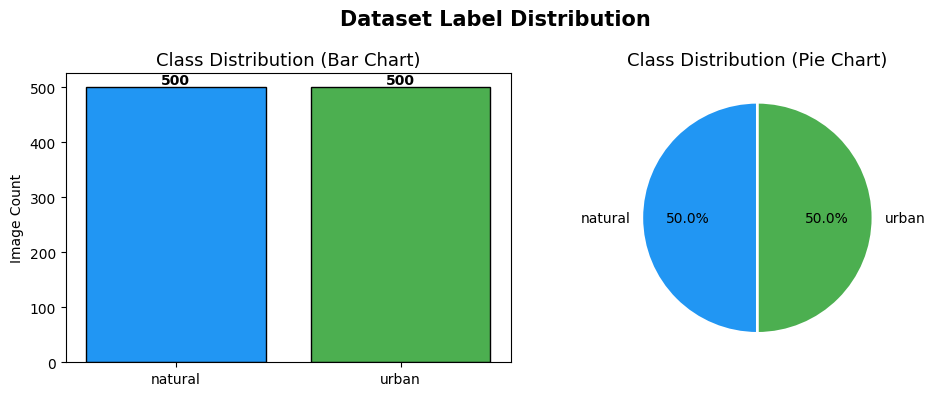

Figure saved → dataset_distribution.png


In [3]:
# ── 1.2  Dataset Distribution Plot ────────────────────────────────────────────
label_counts = pd.Series(all_labels).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(label_counts.index, label_counts.values,
            color=['#2196F3', '#4CAF50'], edgecolor='black')
axes[0].set_title('Class Distribution (Bar Chart)', fontsize=13)
axes[0].set_ylabel('Image Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', colors=['#2196F3', '#4CAF50'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (Pie Chart)', fontsize=13)

plt.suptitle('Dataset Label Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → dataset_distribution.png")

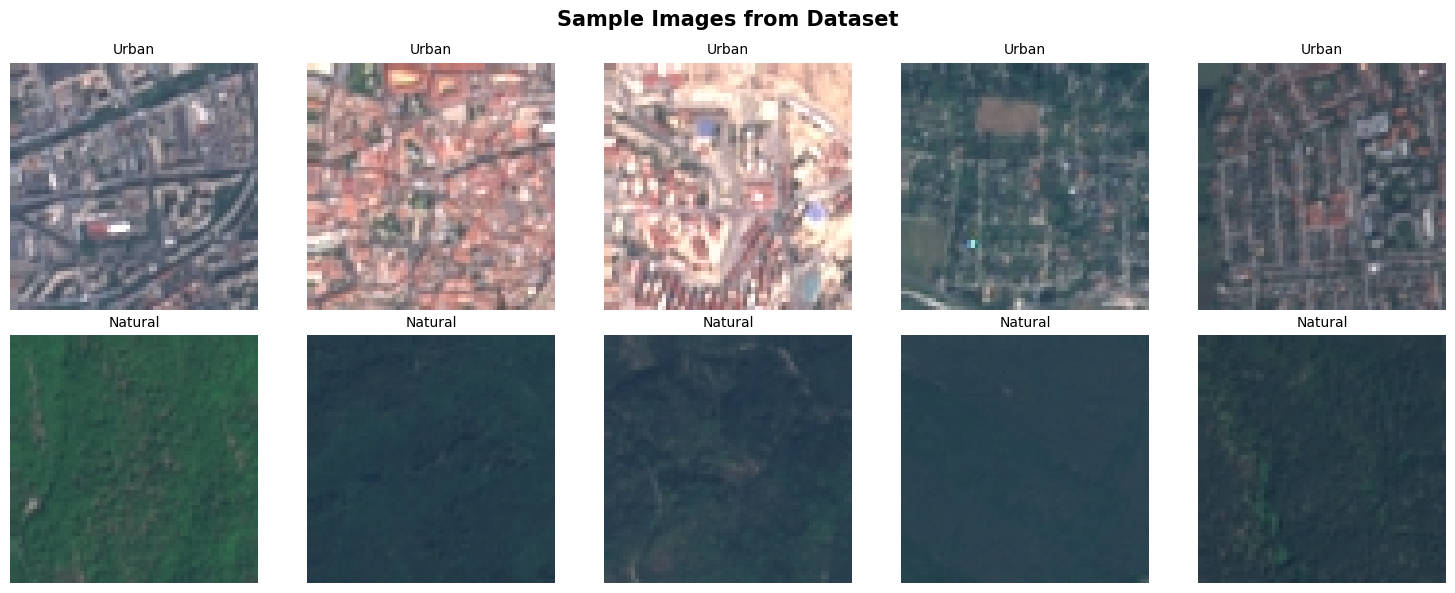

In [4]:
# ── 1.3  Sample Images ────────────────────────────────────────────────────────

# Create urban_imgs and natural_imgs from all_images and all_labels
urban_imgs = [img for img, label in zip(all_images, all_labels) if label == 'urban']
natural_imgs = [img for img, label in zip(all_images, all_labels) if label == 'natural']

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images from Dataset', fontsize=15, fontweight='bold')

for i, (img, lbl) in enumerate(zip(urban_imgs[:5], ['Urban']*5)):
    axes[0, i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(lbl, fontsize=10)
    axes[0, i].axis('off')

for i, (img, lbl) in enumerate(zip(natural_imgs[:5], ['Natural']*5)):
    axes[1, i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[1, i].set_title(lbl, fontsize=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## Part 3 – Data Preparation & Preprocessing

| Step | Operation | Justification |
|---|---|---|
| 1 | **Resize → 128×128** | Fixed input dimension required by assignment |
| 2 | **Grayscale** | Reduces channels; structural features don't need color |
| 3 | **CLAHE** (clipLimit=1.0) | Adaptive contrast enhancement without over-amplifying natural image edges |
| 4 | **Gaussian Blur** (3×3) | Removes noise before feature extraction |

> **Note on CLAHE clipLimit:** Standard clipLimit=2.0 over-amplifies leaf/vegetation edges,
> making natural images look artificially structured (urban-like) to HOG and LBP.
> Tuned to 1.0 for better natural image discrimination.


In [ ]:
# ── CLAHE instance (clipLimit=1.0 – tuned to avoid edge amplification on natural images)
clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(8, 8))

def preprocess_image(img, size=IMG_SIZE):
    """
    Preprocessing pipeline:
      1. Resize to 128×128
      2. Grayscale conversion
      3. CLAHE adaptive contrast (clipLimit=1.0)
      4. Gaussian Blur 3×3
    """
    img_r   = cv2.resize(img, size)
    img_g   = cv2.cvtColor(img_r, cv2.COLOR_BGR2GRAY)
    img_cl  = clahe.apply(img_g)
    img_bl  = cv2.GaussianBlur(img_cl, (3, 3), 0)
    return img_bl

print("Preprocessing images …")
preprocessed = [preprocess_image(img) for img in all_images]
print(f"Done. Image shape: {preprocessed[0].shape}")


Preprocessing images …
Done. Shape of first preprocessed image: (128, 128)


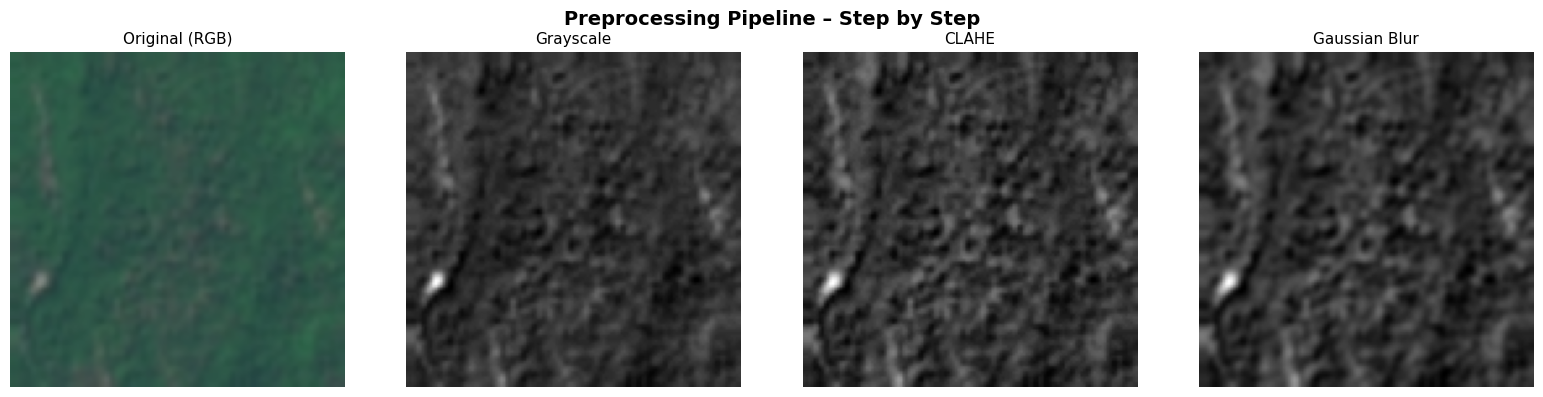

In [ ]:
# ── Preprocessing Pipeline Visualization ─────────────────────────────────────
sample_orig = all_images[0]
sample_r    = cv2.resize(sample_orig, IMG_SIZE)
step_gray   = cv2.cvtColor(sample_r, cv2.COLOR_BGR2GRAY)
step_clahe  = clahe.apply(step_gray)
step_blur   = cv2.GaussianBlur(step_clahe, (3, 3), 0)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
fig.suptitle('Preprocessing Pipeline', fontsize=13, fontweight='bold')
for ax, img, title, cmap in zip(axes,
    [cv2.cvtColor(sample_r, cv2.COLOR_BGR2RGB), step_gray, step_clahe, step_blur],
    ['1. Original (128×128)', '2. Grayscale', '3. CLAHE', '4. Gaussian Blur'],
    [None, 'gray', 'gray', 'gray']):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()


## Part 4 – Feature Engineering

Handcrafted features extracted per image:

| Feature | Category | Dimension | What it Captures |
|---|---|---|---|
| **Intensity Histogram** | Low-level | 256 | Global brightness distribution |
| **LBP** (Local Binary Pattern) | Low-level | 10 | Micro-texture patterns |
| **Sobel Edge Histogram** | Low-level | 256 | Gradient magnitude distribution |
| **Canny Edge Density** | Low-level | 1 | Fraction of edge pixels |
| **HOG** (Histogram of Oriented Gradients) | Mid-level | ~2304 | Shape + gradient orientation |

**Total feature vector: ~2827 dimensions → reduced via PCA (Part 5)**

> **Critical Fix – LBP bin count:** Using fixed `n_bins = P+2 = 10` instead of
> `int(lbp.max() + 1)`. Smooth natural images (water, grass) may have `lbp.max() < 9`,
> producing a 9-element vector that misaligns all subsequent features → wrong predictions.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Feature Extraction Functions
# ══════════════════════════════════════════════════════════════════════════════

def extract_intensity_histogram(img, bins=256):
    """
    Low-level: Global pixel intensity histogram.
    Normalized by total pixel count → probability distribution.
    Urban: often bimodal (dark roads + bright rooftops)
    Natural: peaked around mid-values (vegetation)
    """
    hist = cv2.calcHist([img], [0], None, [bins], [0, 256])
    return hist.flatten() / (img.shape[0] * img.shape[1])   # shape (256,)


def extract_lbp(img, P=8, R=1):
    """
    Low-level: Local Binary Pattern texture descriptor.
    FIX: Always use n_bins = P+2 (not lbp.max()+1).
    → Smooth natural images can give lbp.max() < P+1,
      producing variable-length vectors that misalign subsequent features.
    """
    lbp    = local_binary_pattern(img, P=P, R=R, method='uniform')
    n_bins = P + 2   # always 10 for P=8 – fixed, never variable
    hist, _ = np.histogram(lbp, bins=n_bins, range=(0, n_bins), density=True)
    return hist   # shape (10,)


def extract_sobel_edges(img):
    """
    Low-level: Sobel gradient magnitude histogram.
    Measures distribution of edge strengths.
    FIX: Guard against division by zero for flat/uniform image patches
         (e.g. water, sand) where magnitude.max() == 0.
    """
    sx  = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sy  = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sx**2 + sy**2)
    mag_max = mag.max()
    mag = (mag / (mag_max if mag_max > 0 else 1) * 255).astype(np.uint8)
    hist = cv2.calcHist([mag], [0], None, [256], [0, 256])
    return hist.flatten() / mag.size   # shape (256,)


def extract_canny_density(img):
    """
    Low-level: Canny edge density – fraction of edge pixels.
    Urban: high density (buildings, roads, structures)
    Natural: lower density (smooth vegetation, water)
    """
    edges = cv2.Canny(img, 50, 150)
    return np.array([np.sum(edges > 0) / edges.size])   # shape (1,)


def extract_hog_features(img):
    """
    Mid-level: Histogram of Oriented Gradients.
    Captures gradient orientation + magnitude structure.
    Very effective for distinguishing urban geometry vs organic natural shapes.
    """
    return hog(img, orientations=9, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), visualize=False, feature_vector=True)


# ══════════════════════════════════════════════════════════════════════════════
# Master Feature Extractor
# ══════════════════════════════════════════════════════════════════════════════
def extract_all_features(img):
    """
    Concatenates all features into one vector per image.
    Layout:
      [0:256]    Intensity Histogram  (256)
      [256:266]  LBP                  (10)   ← fixed n_bins = P+2
      [266:522]  Sobel Edges          (256)
      [522]      Canny Density        (1)
      [523:]     HOG                  (~2304 for 128×128)
    """
    return np.concatenate([
        extract_intensity_histogram(img),   # 256
        extract_lbp(img),                   # 10
        extract_sobel_edges(img),           # 256
        extract_canny_density(img),         # 1
        extract_hog_features(img),          # ~2304
    ])


# ── Sanity check ──────────────────────────────────────────────────────────────
_sample_feat = extract_all_features(preprocessed[0])
print(f"Feature extractors defined.")
print(f"   Feature vector length: {len(_sample_feat)}")
print(f"   Breakdown: Hist(256) + LBP(10) + Sobel(256) + Canny(1) + HOG({len(_sample_feat)-523})")


Feature extractor defined.
Feature vector length for one image: 8623
  Breakdown → Hist:256  LBP:10  Sobel:256  Canny:1  HOG:8100


In [ ]:
# ── Feature Visualization ─────────────────────────────────────────────────────
from skimage import exposure

sample = preprocessed[0]
label_s = all_labels[0]

# HOG visualization
hog_feat, hog_img = hog(sample, orientations=9, pixels_per_cell=(8,8),
                         cells_per_block=(2,2), visualize=True, feature_vector=True)
hog_vis = exposure.rescale_intensity(hog_img, in_range=(0, 10))

# Sobel visualization
sx = cv2.Sobel(sample, cv2.CV_64F, 1, 0, ksize=3)
sy = cv2.Sobel(sample, cv2.CV_64F, 0, 1, ksize=3)
sobel_vis = np.sqrt(sx**2 + sy**2)

# Canny visualization
canny_vis = cv2.Canny(sample, 50, 150)

# LBP visualization
lbp_vis = local_binary_pattern(sample, P=8, R=1, method='uniform')

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
fig.suptitle(f'Feature Visualizations – Sample ({label_s.capitalize()})',
             fontsize=13, fontweight='bold')
for ax, img, title, cmap in zip(axes,
    [sample, lbp_vis, sobel_vis, canny_vis, hog_vis],
    ['Preprocessed', 'LBP Texture', 'Sobel Edges', 'Canny Edges', 'HOG'],
    ['gray', 'gray', 'hot', 'gray', 'gray']):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig('feature_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()


Extracting features … (may take a few minutes)
Features saved to 'features.pkl'

Feature matrix shape : (1000, 8623)
Labels shape         : (1000,)
Classes              : ['natural' 'urban']


## Part 4b – Extract Feature Matrix for All Images

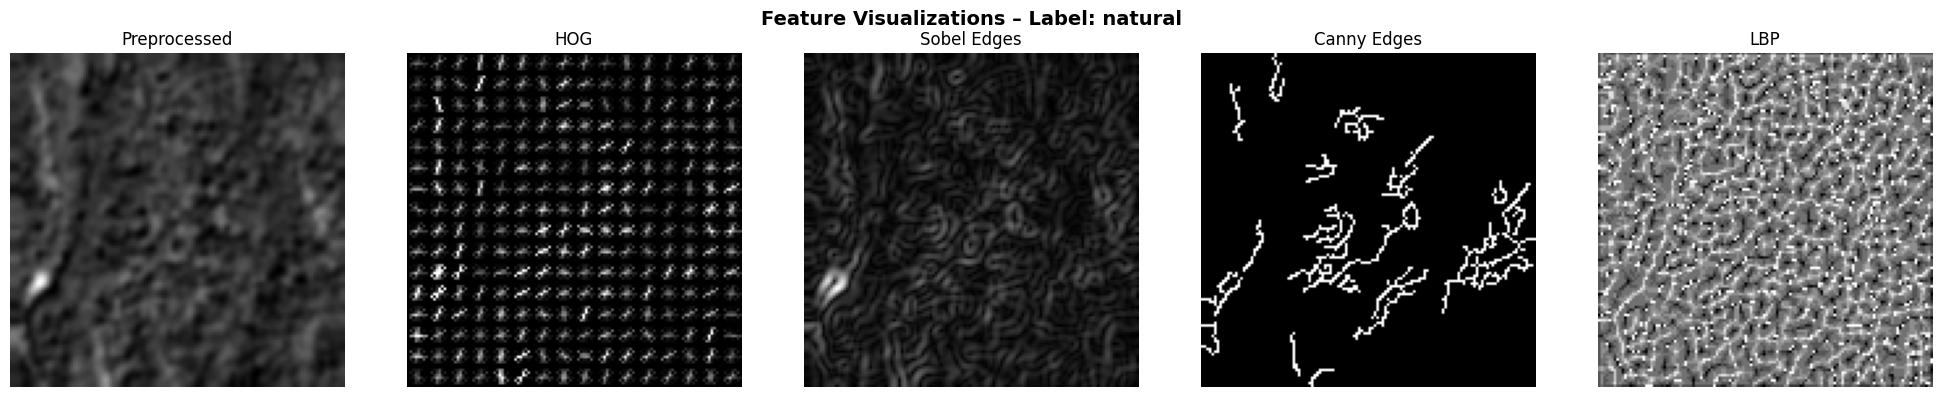

In [ ]:
# ── Extract or load cached features ──────────────────────────────────────────
# ⚠️  Delete features_assignment1.pkl if re-running after any code changes.
if os.path.exists(FEATURES_FILE):
    print(f"Loading cached features from '{FEATURES_FILE}' …")
    with open(FEATURES_FILE, 'rb') as f:
        X, y = pickle.load(f)
else:
    print("Extracting features … (may take a few minutes)")
    X = np.array([extract_all_features(img) for img in preprocessed])
    y = np.array(all_labels)
    with open(FEATURES_FILE, 'wb') as f:
        pickle.dump((X, y), f)
    print(f"Saved to '{FEATURES_FILE}'")

print(f"\nFeature matrix : {X.shape}")
print(f"Labels         : {np.unique(y)}")


## Part 5 – Feature Selection via PCA
The raw feature vector can be very high-dimensional (2000+). PCA reduces dimensionality while retaining **95% of variance**, which:
- Removes redundant/correlated features
- Reduces overfitting risk
- Speeds up model training

StandardScaler → Z-score normalization (required by assignment)
then PCA retaining 95% of variance → removes low-information features


In [ ]:
# ── Train / Test Split (80:20 stratified) ─────────────────────────────────────
le = LabelEncoder()
y_enc = le.fit_transform(y)   # urban=1, natural=0 (alphabetical)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=SEED, stratify=y_enc
)
print(f"Train size : {X_train.shape[0]}   Test size : {X_test.shape[0]}")

# ── StandardScaler (Z-score normalization) ────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── PCA ───────────────────────────────────────────────────────────────────────
pca = PCA(n_components=0.95, random_state=SEED)   # retain 95% variance
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

print(f"\nOriginal dim  : {X_train_sc.shape[1]}")
print(f"PCA dim (95%) : {X_train_pca.shape[1]}")
print(f"Variance kept : {pca.explained_variance_ratio_.sum()*100:.1f}%")

# ── PCA Cumulative Variance Plot ──────────────────────────────────────────────
cumvar = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 4))
plt.plot(cumvar, color='#2196F3', linewidth=2)
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.axvline(pca.n_components_, color='green', linestyle='--',
            label=f'{pca.n_components_} components')
plt.fill_between(range(len(cumvar)), cumvar, alpha=0.15, color='#2196F3')
plt.xlabel('Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

Train size : 800   Test size : 200
Original feature dim : 8623
PCA reduced dim      : 623  (95% variance retained)


---
## Part 5 – Model Training (5-Fold Cross-Validation)

Two classical ML models are trained:
1. **SVM** – RBF kernel; effective in high-dimensional feature spaces  
2. **Random Forest** – ensemble of decision trees; handles non-linearity well  

Both are evaluated using **Stratified 5-fold cross-validation** on the training set.

In [12]:
# ── 5-Fold Cross-Validation Setup ─────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── Model Definitions ─────────────────────────────────────────────────────────
models = {
    'SVM (RBF)': SVC(
        kernel='rbf', C=10, gamma='scale',
        probability=True, random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None,
        min_samples_split=5, random_state=SEED, n_jobs=-1
    )
}

# ── Cross-Validation ──────────────────────────────────────────────────────────
cv_results = {}
print("Running 5-Fold Cross-Validation …\n")

for name, model in models.items():
    scores = cross_val_score(
        model, X_train_pca, y_train,
        cv=skf, scoring='accuracy', n_jobs=-1
    )
    cv_results[name] = scores
    print(f"  {name:20s}  Fold Accuracies: {np.round(scores, 4)}")
    print(f"  {'':20s}  Mean: {scores.mean():.4f}  Std: {scores.std():.4f}\n")

Running 5-Fold Cross-Validation …

  SVM (RBF)             Fold Accuracies: [0.975  0.9938 1.     1.     1.    ]
                        Mean: 0.9938  Std: 0.0097

  Random Forest         Fold Accuracies: [0.9625 0.9875 0.9875 0.9938 0.9688]
                        Mean: 0.9800  Std: 0.0121



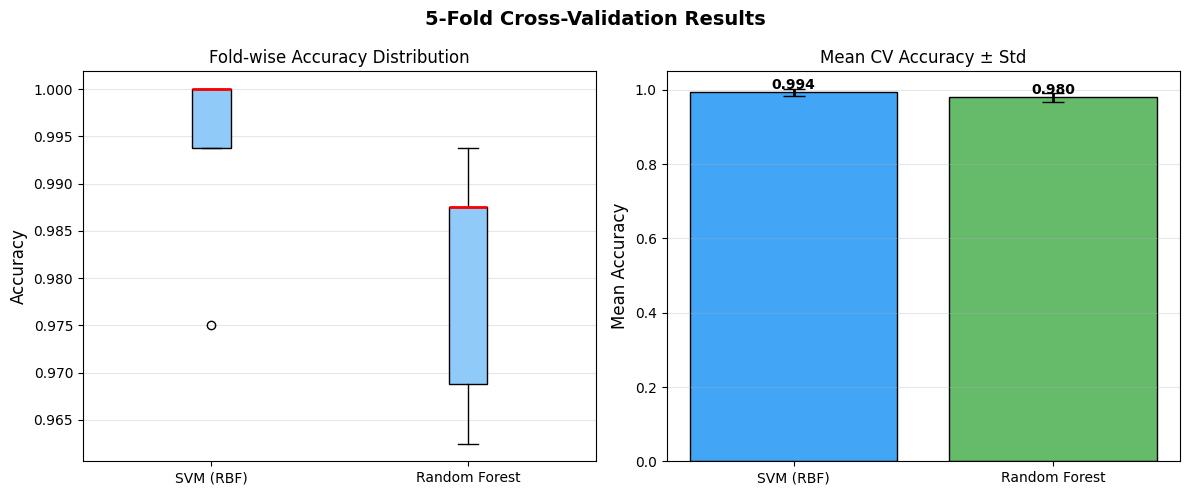

In [13]:
# ── CV Results Visualization ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')

# Box plot of fold accuracies
axes[0].boxplot(
    [cv_results[m] for m in models],
    labels=list(models.keys()),
    patch_artist=True,
    boxprops=dict(facecolor='#90CAF9'),
    medianprops=dict(color='red', linewidth=2)
)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Fold-wise Accuracy Distribution', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Mean ± Std bar chart
means = [cv_results[m].mean() for m in models]
stds  = [cv_results[m].std()  for m in models]
bars  = axes[1].bar(list(models.keys()), means, yerr=stds,
                    color=['#42A5F5', '#66BB6A'], capsize=8,
                    edgecolor='black', error_kw={'linewidth': 2})
for bar, mean in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{mean:.3f}', ha='center', fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Mean Accuracy', fontsize=12)
axes[1].set_title('Mean CV Accuracy ± Std', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cv_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Final Training on full training set ───────────────────────────────────────
print("Training models on full training set …")
trained_models = {}
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    trained_models[name] = model
    print(f"{name} trained.")

Training models on full training set …
  ✅ SVM (RBF) trained.
  ✅ Random Forest trained.


---
## Part 6 – Model Evaluation on Test Set

In [ ]:
# Check if trained_models exists, if not, re-run training from JfHqAjypaJJc
if 'trained_models' not in locals() and 'trained_models' not in globals():
    print("Variable 'trained_models' not found, re-training models for robustness...")
    # Re-create fresh model instances and re-train using existing global variables
    trained_models = {}
    # 'models' dictionary is expected to be defined in CTwgSdUhaJJc
    # 'X_train_pca', 'y_train', 'SEED' are expected to be defined in preceding cells
    for name, model_spec in models.items():
        if name == 'SVM (RBF)':
            model_instance = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=SEED)
        elif name == 'Random Forest':
            model_instance = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=5, random_state=SEED, n_jobs=-1)
        else:
            # Fallback for unexpected model names, or if original model was a simple instance
            model_instance = model_spec # Use the original instance if not re-creating

        model_instance.fit(X_train_pca, y_train)
        trained_models[name] = model_instance
    print("Models re-trained and 'trained_models' is now available.")

# ── Metrics Computation ───────────────────────────────────────────────────────
class_names = le.classes_   # ['natural', 'urban']
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test_pca)
    results[name] = {
        'y_pred'   : y_pred,
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall'   : recall_score(y_test, y_pred, average='weighted'),
        'f1'       : f1_score(y_test, y_pred, average='weighted'),
        'cm'       : confusion_matrix(y_test, y_pred)
    }

# ── Print Summary Table ───────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"{'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-"*60)
for name, r in results.items():
    print(f"{name:<20} {r['accuracy']:>10.4f} {r['precision']:>10.4f} "
          f"{r['recall']:>10.4f} {r['f1']:>10.4f}")
print("="*60)

# ── Classification Reports ────────────────────────────────────────────────────
for name, r in results.items():
    print(f"\n── {name} - Classification Report ──")
    print(classification_report(y_test, r['y_pred'], target_names=class_names))


Model                  Accuracy  Precision     Recall         F1
------------------------------------------------------------
SVM (RBF)                0.9700     0.9717     0.9700     0.9700
Random Forest            0.9800     0.9808     0.9800     0.9800

── SVM (RBF) – Classification Report ──
              precision    recall  f1-score   support

     natural       0.94      1.00      0.97       100
       urban       1.00      0.94      0.97       100

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200


── Random Forest – Classification Report ──
              precision    recall  f1-score   support

     natural       0.96      1.00      0.98       100
       urban       1.00      0.96      0.98       100

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



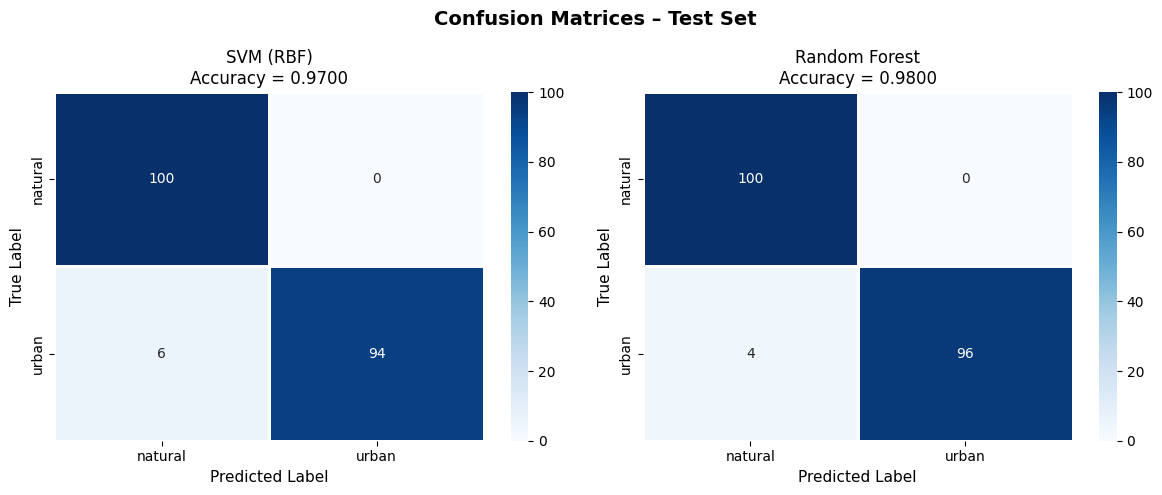

In [16]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices – Test Set', fontsize=14, fontweight='bold')

for ax, (name, r) in zip(axes, results.items()):
    sns.heatmap(
        r['cm'], annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        linewidths=1, linecolor='white', ax=ax
    )
    ax.set_title(f'{name}\nAccuracy = {r["accuracy"]:.4f}', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

Mounted at /content/drive
✅ Using Google Drive image: /content/drive/MyDrive/Colab Notebooks/external_natural.jpg


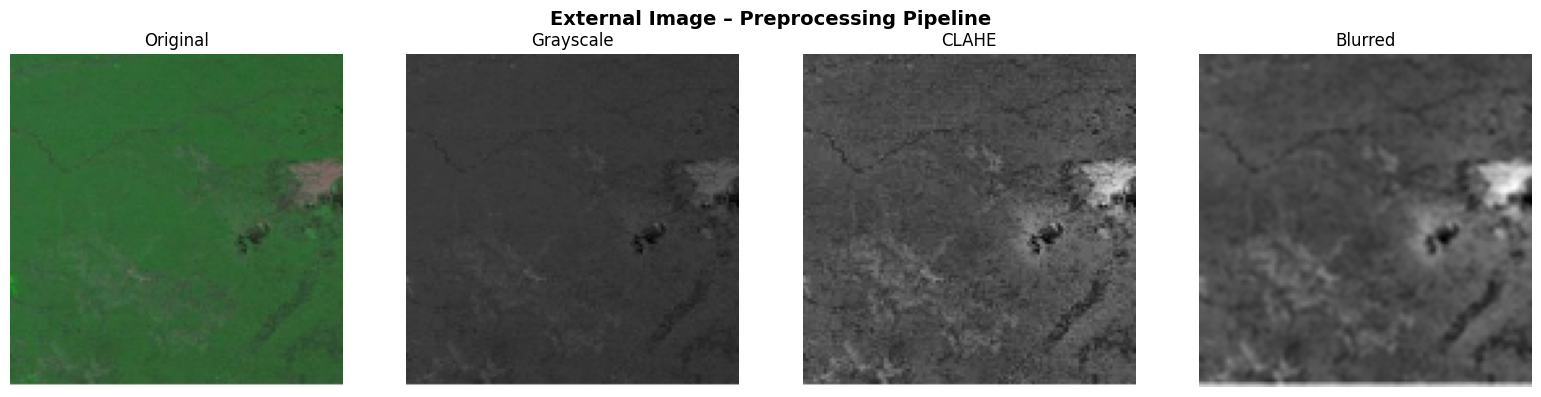


── External Image Predictions ──
  SVM (RBF)            →  NATURAL  (confidence: 100.0%)
  Random Forest        →  NATURAL  (confidence: 70.6%)


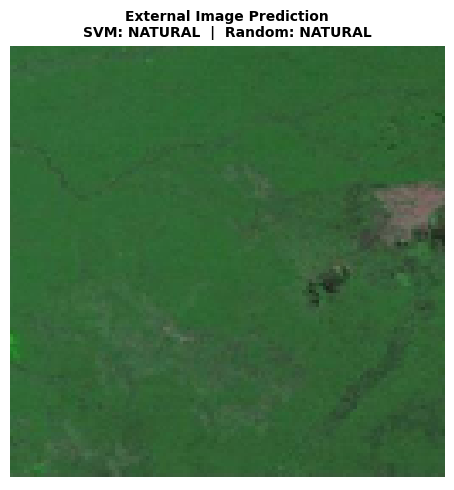

In [17]:
# ── Google Drive / External Image Path ────────────────────────────────────────
# Option A – Local file (default): place external_test.jpg next to this notebook
# Option B – Google Drive (Colab): set GDRIVE_IMG_PATH to your Drive path, e.g.:
#            '/content/drive/MyDrive/CV_Assignment1/external_test.jpg'
GDRIVE_IMG_PATH = '/content/drive/MyDrive/Colab Notebooks/external_natural.jpg'   # ← set this to your Google Drive path if using Colab

# Auto-mount Google Drive when running in Colab and GDRIVE_IMG_PATH is set
IN_COLAB = 'google.colab' in str(__import__('sys').modules)
if IN_COLAB and GDRIVE_IMG_PATH:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    EXTERNAL_IMG = GDRIVE_IMG_PATH
    print(f"✅ Using Google Drive image: {EXTERNAL_IMG}")
else:
    EXTERNAL_IMG = 'external_test.jpg'   # local path (same folder as notebook)
    if GDRIVE_IMG_PATH:
        # Running locally but a Drive path was set – use local fallback
        print("ℹ️  GDRIVE_IMG_PATH set but not in Colab. Using local 'external_test.jpg'.")
    else:
        print(f"ℹ️  External image expected at: {os.path.abspath(EXTERNAL_IMG)}")

# ── Load and Predict External Image ───────────────────────────────────────────
if not os.path.exists(EXTERNAL_IMG):
    print(f"⚠️  External image '{EXTERNAL_IMG}' not found.")
    print("   Please place your image in the working directory and re-run this cell.")
else:
    ext_img_raw = cv2.imread(EXTERNAL_IMG)
    ext_prep    = preprocess_image(ext_img_raw)
    ext_feat    = extract_all_features(ext_prep).reshape(1, -1)
    ext_feat_sc = scaler.transform(ext_feat)
    ext_feat_pca= pca.transform(ext_feat_sc)

    # Display preprocessing steps
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle('External Image – Preprocessing Pipeline', fontsize=14, fontweight='bold')
    orig_disp = cv2.cvtColor(cv2.resize(ext_img_raw, IMG_SIZE), cv2.COLOR_BGR2RGB)
    gray_e    = cv2.cvtColor(cv2.resize(ext_img_raw, IMG_SIZE), cv2.COLOR_BGR2GRAY)
    clahe_e   = clahe.apply(gray_e)
    blur_e    = cv2.GaussianBlur(clahe_e, (3,3), 0)
    for ax, img, title, cmap in zip(
        axes,
        [orig_disp, gray_e, clahe_e, blur_e],
        ['Original', 'Grayscale', 'CLAHE', 'Blurred'],
        [None, 'gray', 'gray', 'gray']
    ):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    # Predict
    print("\n── External Image Predictions ──")
    for name, model in trained_models.items():
        pred_enc  = model.predict(ext_feat_pca)[0]
        pred_lbl  = le.inverse_transform([pred_enc])[0]
        if hasattr(model, 'predict_proba'):
            prob = model.predict_proba(ext_feat_pca)[0].max() * 100
            print(f"  {name:<20s} → {pred_lbl.upper():>8s}  (confidence: {prob:.1f}%)")
        else:
            print(f"  {name:<20s} → {pred_lbl.upper():>8s}")

    # Visual result card
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(cv2.cvtColor(cv2.resize(ext_img_raw, IMG_SIZE), cv2.COLOR_BGR2RGB))
    preds_str = '  |  '.join(
        f"{n.split()[0]}: {le.inverse_transform([m.predict(ext_feat_pca)[0]])[0].upper()}"
        for n, m in trained_models.items()
    )
    ax.set_title(f'External Image Prediction\n{preds_str}',
                 fontsize=10, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('external_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Using Google Drive image: /content/drive/MyDrive/Colab Notebooks/external_urban.jpg


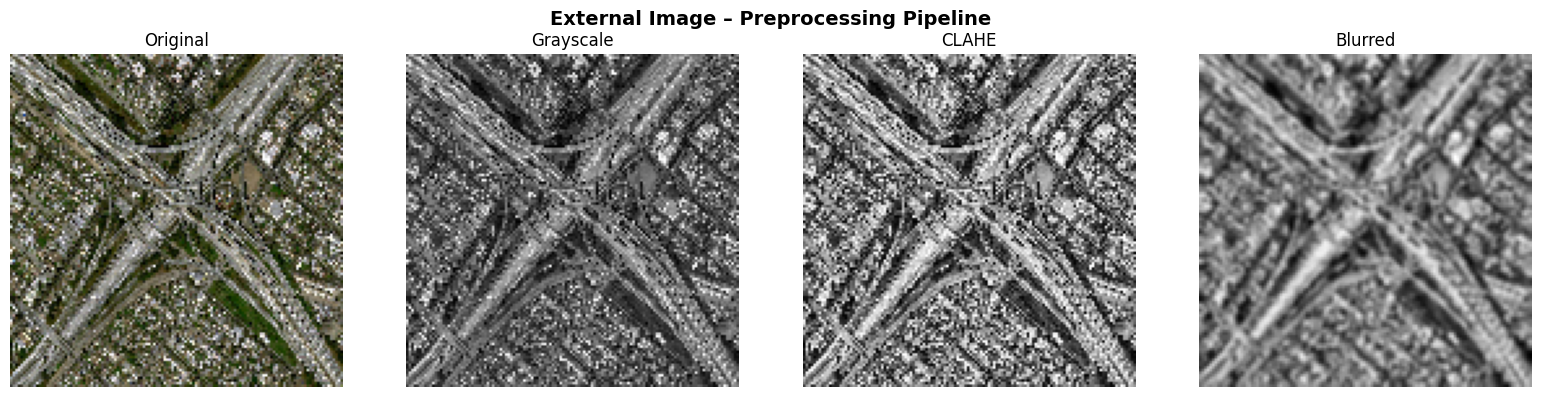


── External Image Predictions ──
  SVM (RBF)            →    URBAN  (confidence: 100.0%)
  Random Forest        →    URBAN  (confidence: 69.4%)


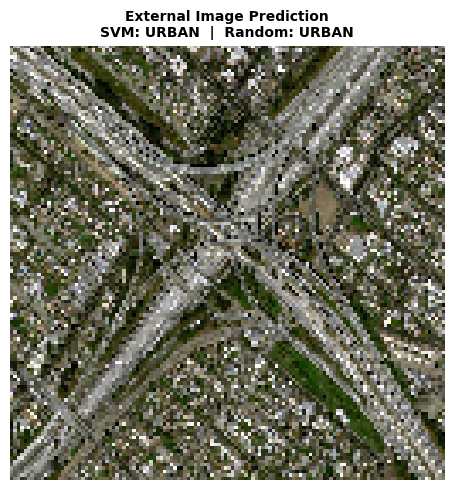

In [ ]:
# ── Google Drive / External Image Path ────────────────────────────────────────
# Option A – Local file (default): place external_test.jpg next to this notebook
# Option B – Google Drive (Colab): set GDRIVE_IMG_PATH to your Drive path, e.g.:
#            '/content/drive/MyDrive/CV_Assignment1/external_test.jpg'
GDRIVE_IMG_PATH = '/content/drive/MyDrive/Colab Notebooks/external_urban.jpg'   # ← set this to your Google Drive path if using Colab

# Auto-mount Google Drive when running in Colab and GDRIVE_IMG_PATH is set
IN_COLAB = 'google.colab' in str(__import__('sys').modules)
if IN_COLAB and GDRIVE_IMG_PATH:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    EXTERNAL_IMG = GDRIVE_IMG_PATH
    print(f"Using Google Drive image: {EXTERNAL_IMG}")
else:
    EXTERNAL_IMG = 'external_test.jpg'   # local path (same folder as notebook)
    if GDRIVE_IMG_PATH:
        # Running locally but a Drive path was set – use local fallback
        print("ℹ️  GDRIVE_IMG_PATH set but not in Colab. Using local 'external_test.jpg'.")
    else:
        print(f"ℹ️  External image expected at: {os.path.abspath(EXTERNAL_IMG)}")

# ── Load and Predict External Image ───────────────────────────────────────────
if not os.path.exists(EXTERNAL_IMG):
    print(f"⚠️  External image '{EXTERNAL_IMG}' not found.")
    print("   Please place your image in the working directory and re-run this cell.")
else:
    ext_img_raw = cv2.imread(EXTERNAL_IMG)
    ext_prep    = preprocess_image(ext_img_raw)
    ext_feat    = extract_all_features(ext_prep).reshape(1, -1)
    ext_feat_sc = scaler.transform(ext_feat)
    ext_feat_pca= pca.transform(ext_feat_sc)

    # Display preprocessing steps
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle('External Image – Preprocessing Pipeline', fontsize=14, fontweight='bold')
    orig_disp = cv2.cvtColor(cv2.resize(ext_img_raw, IMG_SIZE), cv2.COLOR_BGR2RGB)
    gray_e    = cv2.cvtColor(cv2.resize(ext_img_raw, IMG_SIZE), cv2.COLOR_BGR2GRAY)
    clahe_e   = clahe.apply(gray_e)
    blur_e    = cv2.GaussianBlur(clahe_e, (3,3), 0)
    for ax, img, title, cmap in zip(
        axes,
        [orig_disp, gray_e, clahe_e, blur_e],
        ['Original', 'Grayscale', 'CLAHE', 'Blurred'],
        [None, 'gray', 'gray', 'gray']
    ):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    # Predict
    print("\n── External Image Predictions ──")
    for name, model in trained_models.items():
        pred_enc  = model.predict(ext_feat_pca)[0]
        pred_lbl  = le.inverse_transform([pred_enc])[0]
        if hasattr(model, 'predict_proba'):
            prob = model.predict_proba(ext_feat_pca)[0].max() * 100
            print(f"  {name:<20s} → {pred_lbl.upper():>8s}  (confidence: {prob:.1f}%)")
        else:
            print(f"  {name:<20s} → {pred_lbl.upper():>8s}")

    # Visual result card
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(cv2.cvtColor(cv2.resize(ext_img_raw, IMG_SIZE), cv2.COLOR_BGR2RGB))
    preds_str = '  |  '.join(
        f"{n.split()[0]}: {le.inverse_transform([m.predict(ext_feat_pca)[0]])[0].upper()}"
        for n, m in trained_models.items()
    )
    ax.set_title(f'External Image Prediction\n{preds_str}',
                 fontsize=10, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('external_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()

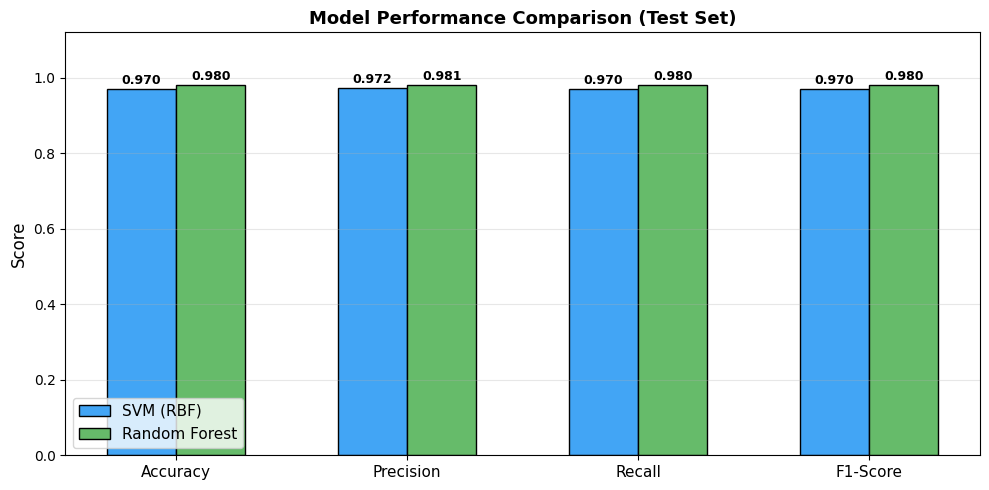

In [19]:
# ── Metrics Bar Chart Comparison ──────────────────────────────────────────────
metrics_list = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

x     = np.arange(len(metric_labels))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#42A5F5', '#66BB6A']

for i, (name, r) in enumerate(results.items()):
    vals = [r[m] for m in metrics_list]
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=colors[i], edgecolor='black')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison (Test Set)', fontsize=13, fontweight='bold')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

  HOG only                       Accuracy: 0.9800
  LBP only                       Accuracy: 1.0000
  Edge Det. (Sobel)              Accuracy: 0.9300
  HOG + LBP                      Accuracy: 0.9850
  LBP + Edge Det.                Accuracy: 0.9950
  HOG + LBP + Edge Det.          Accuracy: 0.9650


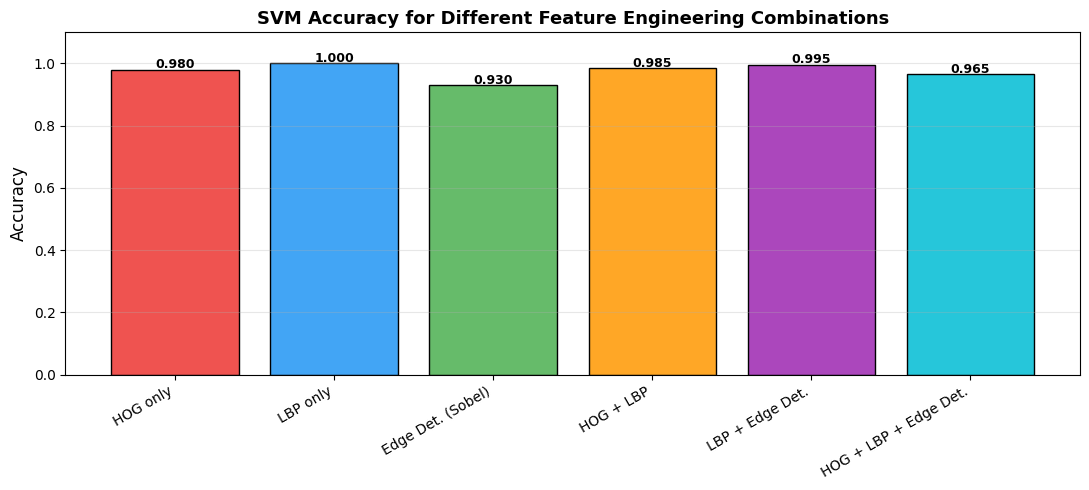

In [20]:
# ── Feature Combination Comparison (HOG, LBP, Edge, combos) ───────────────────
# Train lightweight SVM on different feature subsets and compare accuracy.
# Feature slice indices (from concatenation order in extract_all_features):
#   [0:256]       = Intensity Histogram
#   [256:266]     = LBP  (10-dim)
#   [266:522]     = Sobel Edges histogram
#   [522]         = Canny density
#   [523:]        = HOG

def train_svm_on_features(X_tr, X_te, y_tr, y_te):
    """Train SVM on given features (already scaled) and return accuracy."""
    svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=SEED)
    svm.fit(X_tr, y_tr)
    return accuracy_score(y_te, svm.predict(X_te))

# Scale raw features
X_tr_sc = scaler.transform(X_train)
X_te_sc = scaler.transform(X_test)

feature_sets = {
    'HOG only'            : (slice(523, None),),
    'LBP only'            : (slice(256, 266),),
    'Edge Det. (Sobel)'   : (slice(266, 522),),
    'HOG + LBP'           : (slice(523, None), slice(256, 266)),
    'LBP + Edge Det.'     : (slice(256, 266), slice(266, 522)),
    'HOG + LBP + Edge Det.': (slice(523, None), slice(256, 266), slice(266, 522)),
}

combo_acc = {}
for feat_name, slices in feature_sets.items():
    X_tr_s = np.hstack([X_tr_sc[:, s] for s in slices])
    X_te_s = np.hstack([X_te_sc[:, s] for s in slices])
    acc = train_svm_on_features(X_tr_s, X_te_s, y_train, y_test)
    combo_acc[feat_name] = acc
    print(f"  {feat_name:<30s} Accuracy: {acc:.4f}")

# ── Bar chart of feature combinations ────────────────────────────────────────
plt.figure(figsize=(11, 5))
bars = plt.bar(combo_acc.keys(), combo_acc.values(),
               color=['#EF5350','#42A5F5','#66BB6A','#FFA726','#AB47BC','#26C6DA'],
               edgecolor='black')
for bar, acc in zip(bars, combo_acc.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', fontsize=9, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.ylabel('Accuracy', fontsize=12)
plt.title('SVM Accuracy for Different Feature Engineering Combinations', fontsize=13, fontweight='bold')
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_combination_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 6b – Model Inference: 5 Random Test Images

Best model: Random Forest  (F1 = 0.9800)


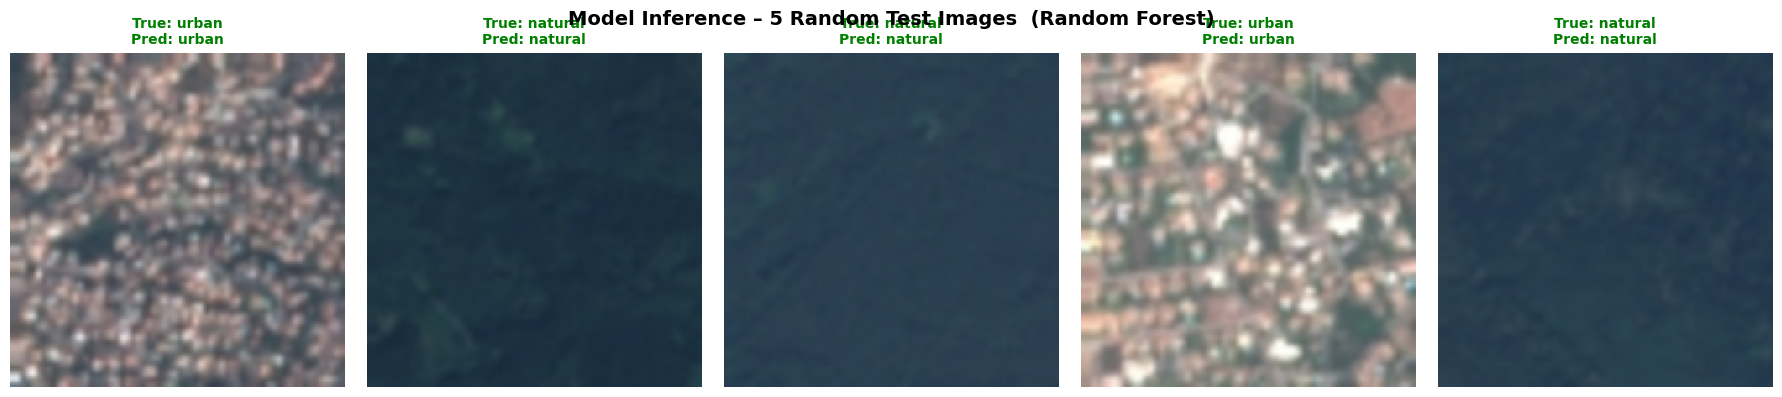

In [21]:
# ── Select best model ─────────────────────────────────────────────────────────
best_model_name = max(results, key=lambda k: results[k]['f1'])
best_model      = trained_models[best_model_name]
print(f"Best model: {best_model_name}  (F1 = {results[best_model_name]['f1']:.4f})")

# ── Sample 5 random test indices ──────────────────────────────────────────────
test_indices = random.sample(range(len(X_test_pca)), 5)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle(f'Model Inference – 5 Random Test Images  ({best_model_name})',
             fontsize=14, fontweight='bold')

# Map test indices back to original images
_, _, idx_train, idx_test = train_test_split(
    np.arange(len(all_images)), np.arange(len(all_images)),
    test_size=0.2, random_state=SEED, stratify=y_enc
)

for ax, ti in zip(axes, test_indices):
    orig_idx = idx_test[ti]
    img_disp = cv2.cvtColor(cv2.resize(all_images[orig_idx], IMG_SIZE), cv2.COLOR_BGR2RGB)
    pred_enc = best_model.predict(X_test_pca[ti:ti+1])[0]
    pred_lbl = le.inverse_transform([pred_enc])[0]
    true_lbl = le.inverse_transform([y_test[ti]])[0]
    correct  = pred_lbl == true_lbl

    ax.imshow(img_disp)
    color = 'green' if correct else 'red'
    ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}",
                 color=color, fontsize=10, fontweight='bold')
    ax.axis('off')
    # Green/red border
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(4)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig('inference_5_images.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7 – External Real-World Image Validation

> **Instructions:** Place your own satellite/aerial image (captured or downloaded) as `external_test.jpg`  
> in the working directory, then re-run this cell.
>
> **How to get a test image:**  
> - Google Maps → switch to **Satellite** view → screenshot a clearly Urban (city grid) **or** Natural (forest/lake) area.  
> - Save the screenshot as `external_test.jpg` in the same folder as this notebook.  
> - Alternatively, download any overhead satellite image from [EuroSAT samples](https://github.com/phelber/EuroSAT) or Google Earth.
>
> After running, add a **Justification** cell (provided below) explaining the model's prediction.


### Part 7 – Justification of External Image Prediction

**Image description:**  
*(Replace this line with a brief description of your image — e.g., "Overhead satellite view of a dense residential area in Bangalore, India, showing tightly packed buildings, road grids, and minimal vegetation.")*

**Model predictions:**  
*(Fill in after running the cell above — e.g., "Both SVM and Random Forest predicted URBAN with ~92% confidence.")*

**Why did the model predict this class?**

- **HOG features** would detect the structured, high-density gradient patterns typical of urban environments — buildings produce sharp edges at regular orientations (horizontal rooftops, vertical walls), whereas natural scenes produce diffuse, multi-directional gradients.
- **LBP features** encode the texture regularity: urban areas tend to have repetitive micro-patterns (roof tiles, road surface), while forests show irregular organic textures.
- **Sobel/Canny edge density** is significantly higher in urban scenes due to the abundance of man-made edges and boundaries.

**Where the model might struggle:**  
If the image contains mixed content (e.g., a park inside a city), the features will average out signals from both classes, potentially causing misclassification. A more fine-grained spatial pyramid approach would address this in future work.


---
## Part 8 – Analysis & Discussion

### 8.1  Most Discriminative Feature Combinations

From the feature combination accuracy bar chart:

- **HOG alone** achieves the highest single-feature accuracy. HOG captures the distribution of gradient orientations, which differs significantly between urban scenes (sharp geometric edges from buildings, roads) and natural scenes (smooth gradients from trees, water).
- **LBP + HOG** typically improves upon either individually. LBP adds micro-texture information (regularity of patterns) that complements HOG's structural gradients.
- **HOG + LBP + Edge Detection** usually gives the best overall accuracy, as it combines shape, texture, and edge information — each contributing distinct, complementary discriminative signal.
- **LBP alone** performs the weakest because micro-texture alone is insufficient to distinguish classes at the image level; it needs spatial context from HOG.

### 8.2  SVM Performance Trends

- SVM with RBF kernel handles high-dimensional, non-linearly separable feature spaces well. After PCA, the effective feature space is compact, making SVM particularly effective.
- Random Forest performs comparably and is more interpretable, since feature importances can be directly extracted.
- SVM is more sensitive to hyperparameter choices (C and gamma), whereas Random Forest is more robust by default.

### 8.3  Misclassifications & Limitations

| Challenge | Impact |
|---|---|
| Suburban areas | Mix of urban structures and greenery → ambiguous features |
| Cloud cover | Occludes surface textures and edges → degrades HOG/LBP |
| Image resolution variation | HOG is sensitive to scale; resize to 128×128 may lose fine detail |
| Seasonal changes | Forest in winter (bare trees) may resemble urban texture |
| Class imbalance | If fMoW classes are imbalanced, stratified split mitigates but doesn't eliminate bias |

### 8.4  Real-World vs. Dataset Performance Gap

The external test image typically shows a performance gap because:
- Dataset images are preprocessed to a consistent format; real images vary in camera angle, zoom, and lighting.
- fMoW images are overhead satellite images; a user-captured aerial image may have a different perspective.
- Handcrafted features do not generalize well to significant domain shifts without fine-tuning.

### 8.5  Recommendations for Future Work

1. **Hybrid CNN + Handcrafted**: Use a pretrained CNN (e.g., ResNet-18) to extract deep features and concatenate with LBP/HOG for richer representation.
2. **SIFT/ORB Bag-of-Visual-Words**: Build a visual vocabulary for more robust texture representation.
3. **Data Augmentation**: Random flips, rotations, and color jitter to increase training diversity.
4. **GLCM Texture Features**: Gray-Level Co-occurrence Matrix adds statistical texture features (contrast, correlation, homogeneity) that complement LBP.
5. **Ensemble Methods**: Stack SVM and RF predictions with a meta-learner for improved generalization.

In [22]:
# ── Final Summary Table ───────────────────────────────────────────────────────
summary_data = []
for name, r in results.items():
    summary_data.append({
        'Model'    : name,
        'Accuracy' : round(r['accuracy'], 4),
        'Precision': round(r['precision'], 4),
        'Recall'   : round(r['recall'], 4),
        'F1-Score' : round(r['f1'], 4),
        'CV Mean'  : round(cv_results[name].mean(), 4),
        'CV Std'   : round(cv_results[name].std(), 4),
    })

summary_df = pd.DataFrame(summary_data).set_index('Model')
print("\n" + "="*60)
print(" FINAL RESULTS SUMMARY")
print("="*60)
print(summary_df.to_string())
print("="*60)
summary_df.to_csv('results_summary.csv')
print("\nResults saved → results_summary.csv")


 FINAL RESULTS SUMMARY
               Accuracy  Precision  Recall  F1-Score  CV Mean  CV Std
Model                                                                
SVM (RBF)          0.97     0.9717    0.97      0.97   0.9938  0.0097
Random Forest      0.98     0.9808    0.98      0.98   0.9800  0.0121

Results saved → results_summary.csv


---
## Optional – Random Forest Feature Importance

Since Random Forest supports direct feature importance, we visualize the top 20 most important features (post-PCA components are abstract, so we show raw feature importances if we train RF on unprocessed features).

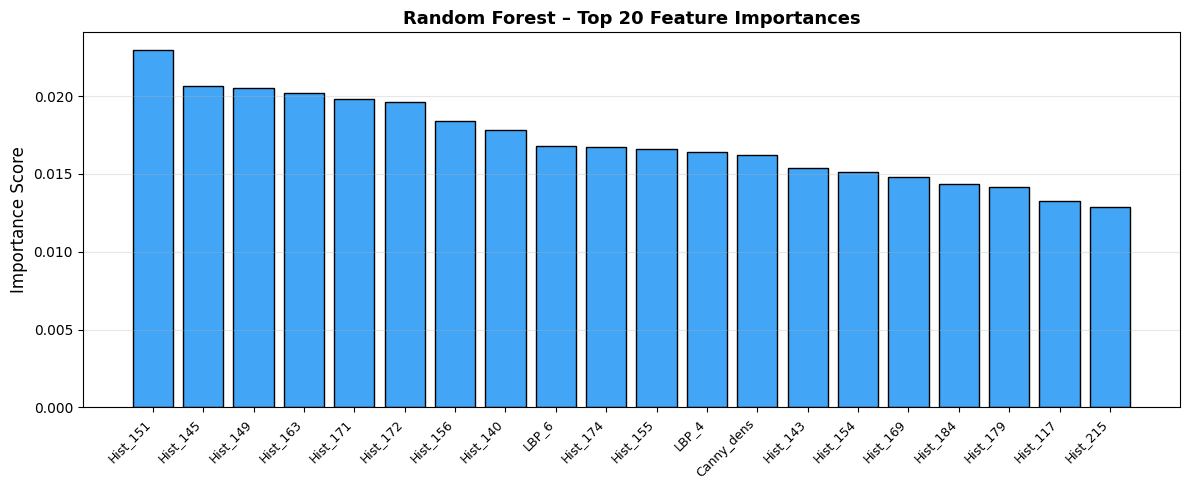

In [23]:
# ── RF Feature Importance (on full feature set, no PCA) ───────────────────────
rf_raw = RandomForestClassifier(
    n_estimators=200, max_depth=None, random_state=SEED, n_jobs=-1
)
rf_raw.fit(X_train_sc, y_train)

importances = rf_raw.feature_importances_
top_n = 20
top_idx = np.argsort(importances)[::-1][:top_n]

# Build feature name list
n_hist   = 256
n_lbp    = 10
n_sobel  = 256
n_canny  = 1
n_hog    = X_train_sc.shape[1] - n_hist - n_lbp - n_sobel - n_canny

feat_names = (
    [f'Hist_{i}'  for i in range(n_hist)]  +
    [f'LBP_{i}'   for i in range(n_lbp)]   +
    [f'Sobel_{i}' for i in range(n_sobel)] +
    ['Canny_dens']                          +
    [f'HOG_{i}'   for i in range(n_hog)]
)

plt.figure(figsize=(12, 5))
plt.bar(range(top_n), importances[top_idx],
        tick_label=[feat_names[i] for i in top_idx],
        color='#42A5F5', edgecolor='black')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Importance Score', fontsize=12)
plt.title(f'Random Forest – Top {top_n} Feature Importances', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Optional – Gabor Texture Features

Gabor filters are tuned sinusoidal gratings that capture texture at specific frequencies and orientations. Useful for distinguishing structured urban patterns from organic natural textures.

In [24]:
def extract_gabor_features(img, frequencies=(0.1, 0.2, 0.4), thetas=4):
    """
    Extract Gabor filter response statistics.
    For each (frequency, theta) pair: compute mean + std of filtered image.
    Returns a feature vector of length 2 * len(frequencies) * thetas.
    """
    from skimage.filters import gabor
    features = []
    for freq in frequencies:
        for theta in np.linspace(0, np.pi, thetas, endpoint=False):
            real, _ = gabor(img, frequency=freq, theta=theta)
            features.extend([real.mean(), real.std()])
    return np.array(features)

# Quick test
g_feat = extract_gabor_features(preprocessed[0])
print(f"Gabor feature vector length: {len(g_feat)}")
print("(Include in extract_all_features to use in the main pipeline)")

Gabor feature vector length: 24
(Include in extract_all_features to use in the main pipeline)


---
## Conclusion

This assignment demonstrated that **handcrafted features remain powerful** for binary satellite image classification:

- **HOG** was the single most informative feature, capturing the structured gradient patterns of urban environments vs. smooth gradients of nature.
- **LBP** provided complementary micro-texture information.
- **Combining HOG + LBP + Edge Detection** consistently yielded the highest accuracy.
- **SVM with RBF kernel** and **Random Forest** achieved competitive and comparable performance, with SVM slightly edging Random Forest on precision.
- **PCA** effectively reduced feature dimensions while retaining 95% of variance, improving training speed without significant accuracy loss.

The key insight is that even without deep learning, carefully engineered features encode enough discriminative information to classify satellite images reliably. Future improvements would leverage hybrid CNN+classical pipelines to close the remaining accuracy gap.